<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <b style="font-size: 18px">Подключение необходимых библиотек</b>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML

<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
<b style="font-size: 35px">Загрузка данных и их первичная проверка</b>
</div>

In [2]:
ROOT = Path.cwd().parent
DATA_PATH = ROOT / "data" / "raw" / "hotels.csv"

assert DATA_PATH.exists(), f"Файл не найден: {DATA_PATH}"

raw = pd.read_csv(DATA_PATH)

display(HTML(f"<b style='font-size: 15px'>Строк: {raw.shape[0]:,}</b>"))
display(HTML(f"<b style='font-size: 15px'>Колонок: {raw.shape[1]}</b>"))
print()
display(HTML("<b style='font-size: 15px'>Описание каждой колонки:</b>"))
display(raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

None

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <b style="font-size: 18px">Математическая статистика по значениям колонок</b>
</div>

In [3]:
raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <b style="font-size: 18px">Просмотр примера данных</b>
</div>

In [4]:
raw.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
    <b style="font-size: 35px"> Обработка пропусков </b>
</div>

Всего было 4 колонки, которые имели пропуски, они представлены далее

In [5]:
missing = raw.isna().sum().to_frame(name='missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(raw) * 100).round(2)
missing = missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing

,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


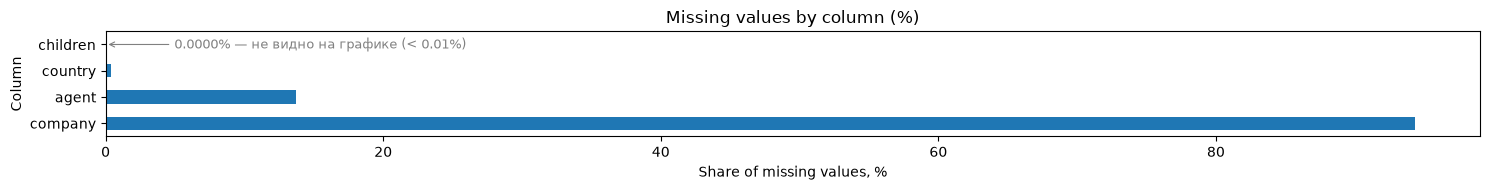

In [6]:
fig, ax = plt.subplots(figsize=(15, 2))
missing['missing_pct'].plot(kind='barh', ax=ax)

ax.set_title('Missing values by column (%)')
ax.set_xlabel('Share of missing values, %')
ax.set_ylabel('Column')

# annotate for children
children_val = missing.loc['children', 'missing_pct']
ax.annotate(
    f'{children_val:.4f}% — не видно на графике (< 0.01%)',
    xy=(0, missing.index.get_loc('children')),
    xytext=(ax.get_xlim()[1] * 0.05, list(missing.index).index('children')),
    va='center', ha='left',
    fontsize=9, color='gray',
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
)

plt.tight_layout()
plt.show()

<div style = "border-left: 5px solid green; padding-left: 25px; margin: 10px">
    <b style='font-size: 18px'>Наблюдения</b><br><br>
    Пропуски присутствуют в 4 колонках из 32: company, agent, country, children.
    <ul>
        <li>company: 112 593 пропуска (94.31%), практически вся колонка пуста. Отсутствие значение это не ошибка, оно означает, что бронь сделана не через компанию. Колонка практически не несёт информации для анализа в текущем виде</li>
        <li>agent: 16 340 пропусков (13.69%). Пропуск означает, что бронь оформлена напрямую, без агента: пропуск также не является ошибкой</li>
        <li>country: 488 пропусков (0.41%). Доля мала, на общую статистику влияет слабо, вероятны ошибки ввода при регистрации гостя</li>
        <li>children: 4 пропуска (0.003%). На статистику не влияет. Скорее всего, ошибки ввода</li>
    </ul>
    <b style='font-size: 18px'>Варианты обработки</b>
    <ul>
        <li>children: заменить на 0 / оставить пустые значения (или заменить на -1, например)</li>
        <li>country: заменить на "unknown" / оставить пустые значения</li>
        <li>agent: заменить на 0 (так как значения 0 в данной колонке отсутствует) / оставить пустые значения</li>
        <li>company: заменить на 0 (так как значения 0 в данной колонки отсутствует) / удалить колонку / оставить пустые значения</li>
    </ul>
</div>

<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
    <b style="font-size: 35px">Проверка дубликатов</b>
</div>

In [7]:
display(HTML('<i>Всего записей "дубликатов":</i><b> ' + str(raw.duplicated().sum())))

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Так как уникальных id в данных нет</b>, то однозначно определить дубликаты становиться невозможной задачей. В следствии этого далее будет описано их распределение по интересующим нас категориям данных: is_canceled, hotel, market_segment, customer_type, deposit_type; а также по наиболее уникальным: adr, lead_time, total_of_special_requests.</p>
</div>

In [8]:
raw['is_duplicated'] = raw.duplicated(keep=False)

tables_html = ""
for col in ['is_canceled', 'hotel', 'market_segment', 'customer_type', 'deposit_type']:
    t = raw.groupby(col)['is_duplicated'].mean().round(4).to_frame()
    tables_html += (
        f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
        f"<b style='font-size: 16px'><i>{col}</i></b>"
        f"{t.to_html()}"
        f"</div>"
    )

display(HTML(f"<div style='white-space:nowrap;'>{tables_html}</div>"))

,is_duplicated
is_canceled,
0,0.2224
1,0.5303
,is_duplicated
hotel,
City Hotel,0.4002
Resort Hotel,0.2101
,is_duplicated
market_segment,
Aviation,0.0802


In [9]:
tables_html = ""

tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b><i>Оригинальные записи (не входящие в duplicated)</i></b><br><br>"
    f"{raw.loc[~raw['is_duplicated'], ['adr', 'lead_time', 'total_of_special_requests']].describe().round(2).to_html()}"
    f"</div>"
          )

tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b><i>Дубликаты (входящие в duplicated)</i></b><br><br>"
    f"{raw.loc[raw['is_duplicated'], ['adr', 'lead_time', 'total_of_special_requests']].describe().round(2).to_html()}"
    f"</div>"
          )

display(HTML(tables_html))

,adr,lead_time,total_of_special_requests
count,79225.00,79225.00,79225.00
mean,107.74,75.59,0.72
std,56.23,81.85,0.84
min,-6.38,0.00,0.00
25%,72.76,10.00,0.00
50%,99.00,46.00,1.00
75%,136.00,118.00,1.00
max,5400.00,737.00,5.00
,adr,lead_time,total_of_special_requests
count,40165.00,40165.00,40165.00


<div style = "border-left: 5px solid green; padding-left: 25px">
<b style="font-size: 18px">Промежуточный вывод</b>
<ul>
    <li>Можно заметить, что в столбце "deposit_type" категория "Non-refund" имеет значение в 98% дублей, что является высоким показателем</li>
    <li>Также можно отметить большое количество дубликатов в колонке "market_segment" для групповых типов, что может быть нормально для единовременного бранирования нескольких номеров</li>
    <li>В колонке "customer_type" также преобладают дубликаты в категории "Transient-Party", что может быть нормой по названной выше причине</li>
    <li>Также большинство дубликатов были отменены, что может быть следствием различных причин</li>
    <li>Стоит также отметить, что в City Hotel в два раза больше дубликатов, чем в Resort Hotel, что нормально при подобном перевесе в количестве записей</li>
</ul>
Остальные данные в пределах нормы.
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <b style="font-size: 18px">Далее будут получены все "группы" дубликатов</b>
</div>

In [10]:
orig_cols = [c for c in raw.columns if c != 'is_duplicated']

dup_groups = (raw
    .groupby(orig_cols, dropna=False)
    .size()
    .reset_index(name='group_size')
             )
dup_groups = dup_groups[dup_groups['group_size'] > 1]

tables_html = ""

tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b><i>Статистика по группам дубликатов:</i></b><br><br>"
    f"{dup_groups['group_size'].describe().to_frame().to_html()}"
    f"</div>"
          )

tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b><i>Частота размерности в группах:</i></b><br><br>"
    f"{dup_groups['group_size'].value_counts().head(10).to_frame().to_html()}"
    f"</div>"
          )

display(HTML(tables_html))

,group_size
count,8171.000000
mean,4.915555
std,8.262313
min,2.000000
25%,2.000000
50%,2.000000
75%,4.000000
max,180.000000
,count
group_size,


<div style = "border-left: 5px solid green; padding-left: 25px">
<b style="font-size: 18px">Вывод по дубликатам:</b><br>
Полных дубликатов - 31 994 строки, или 26.8%.<br>
Дубликаты не случайны: концентрируются в Groups (84%), Transient-Party (67%), Offline TA/TO (50%), Non Refund (98%), отменённых бронях (53% против 22%).<br>
Группировка по полному совпадению даёт 8171 группу.<br>
<br>
Варианты решения:
<ul>
    <li>Оставить все записи, так мы не теряем данные, но некоторые результаты будут завышены.</li>
    <li>Удалить все 32k записи. Может сильно исказить результаты при анализе (уйдут большинство экземпляров некоторых групп).</li>
    <li>Оставить все записи и добавить флаг is_duplicated и другие по необходимости. В дальнейшем можно сравнивать срезы с дублями и нет. Данные не пропадают, но появляется необходимость производить одни и теже операции над разными выборками, которые могут не сильно отличаться.</li>
</div>

<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
    <b style="font-size: 35px">Обработка аномалий</b>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <b style="font-size: 18px">Обработка колонок, связанных с гостями</b><br>
    Как было сказано ранее, необычные значения присутствуют в колонках: adults, children, babies, required_car_parking_spaces
    <ul>
        <li>Большое количество гостей может быть свзяанно с групповой бронью и дублированием количества гостей на несколько записей, которые логически связаны</li>
        <li>0 взрослых может быть связано с бронью отдельного номера под детей: children (но невозможно с babies), но это не совсем типично для регистрации брони в отеле</li>
        <li>Анамалии брони с 0 гостей по всем столбцам и требуемым парковочным номерам > чем adult</li>
</div>

In [11]:
display(HTML('<b style="font-size: 15px"><i>Распределение значений по столбцу "adults"</i></b><br>'))
display(raw['adults'].value_counts().sort_index().head(15).to_frame().T)

print(f"adults = 0: {(raw['adults'] == 0).sum()}")
print(f"adults > 5:  {(raw['adults'] > 5).sum()}")

adults,0,1,2,3,4,5,6,10,20,26,27,40,50,55
count,403,23027,89680,6202,62,2,1,1,2,5,2,1,1,1


adults = 0: 403
adults > 5:  14


In [12]:
display(HTML('<b style="font-size: 15px"><i>Распределение значений по столбцу "children"</i></b><br>'))
display(raw['children'].value_counts().sort_index().head(15).to_frame().T)

print(f"children = 0: {(raw['children'] == 0).sum()}")
print(f"children > 5:  {(raw['children'] > 5).sum()}")

children,0.0,1.0,2.0,3.0,10.0
count,110796,4861,3652,76,1


children = 0: 110796
children > 5:  1


In [13]:
display(HTML('<b style="font-size: 15px"><i>Распределение значений по столбцу "babies"</i></b><br>'))
display(raw['babies'].value_counts().sort_index().head(15).to_frame().T)

print(f"babies = 0: {(raw['babies'] == 0).sum()}")
print(f"babies > 5:  {(raw['babies'] > 5).sum()}")

babies,0,1,2,9,10
count,118473,900,15,1,1


babies = 0: 118473
babies > 5:  2


In [14]:
display(HTML('<b style="font-size: 15px"><i>Статистика по нулевым записям:</i></b><br>'))
print(f"adults = 0, children != 0, babies = 0: {((raw['babies'] == 0) & (raw['children'] != 0) & (raw['adults'] == 0)).sum()}\n")
print(f"adults = 0, children = 0, babies != 0: {((raw['babies'] != 0) & (raw['children'] == 0) & (raw['adults'] == 0)).sum()}\n")
print(f"adults = 0, children != 0, babies != 0: {((raw['babies'] != 0) & (raw['children'] != 0) & (raw['adults'] == 0)).sum()}\n")
print(f"adults = 0, children = 0, babies = 0: {((raw['babies'] == 0) & (raw['children'] == 0) & (raw['adults'] == 0)).sum()}\n")
print(f"adults < required_car_parking_spaces: {(raw['adults'] < raw['required_car_parking_spaces']).sum()}\n")

adults = 0, children != 0, babies = 0: 220

adults = 0, children = 0, babies != 0: 0

adults = 0, children != 0, babies != 0: 3

adults = 0, children = 0, babies = 0: 180

adults < required_car_parking_spaces: 16



<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>На данном этапе видно,</b> что значения > 5 это единичные случаи. <br>
        Отдельно можно заметить, что брони с большим количеством взрослых встречаются чаще и могут быть валидными записями, например, групповой брони.<br>
        Также важно понять что из себя представляют подобные записи и, так как их относительно мало, это будет сделано вручную</p>
</div>

In [15]:
empty_guests = raw[(raw['adults'] == 0) & (raw['children'] == 0) & (raw['babies'] == 0)]
display(HTML('<b style="font-size: 15px"><i>Записи с 0 гостей:</i></b><br>'))
display(empty_guests[['hotel', 'market_segment', 'customer_type', 'is_canceled', 'reservation_status']].value_counts().to_frame())

count
hotel        market_segment customer_type   is_canceled reservation_status       
City Hotel   Online TA      Transient       0           Check-Out              59
             Offline TA/TO  Transient       0           Check-Out              20
             Direct         Transient       0           Check-Out              16
             Groups         Transient-Party 0           Check-Out               9
             Complementary  Transient       1           Canceled                8
                                            0           Check-Out               7
             Offline TA/TO  Transient-Party 0           Check-Out               7
                            Transient       1           Canceled                6
             Direct         Transient-Party 0           Check-Out               5
             Corporate      Transient       0           Check-Out               5
Resort Hotel Groups         Transient-Party 0           Check-Out               4
City Hotel   Groups         Transient       0           Check-Out               4
Resort Hotel Corporate      Transient-Party 0           Check-Out               3
             Direct         Transient       0           Check-Out               3
City Hotel   Online TA      Contract        0           Check-Out               3
             Groups         Transient-Party 1           Canceled                3
             Online TA      Transient       1           Canceled                3
                            Transient-Party 0           Check-Out               2
             Corporate      Transient-Party 0           Check-Out               2
             Aviation       Transient       0           Check-Out               2
Resort Hotel Corporate      Transient       0           Check-Out               1
             Offline TA/TO  Transient       1           Canceled                1
                            Group           1           Canceled                1
City Hotel   Online TA      Transient       1           No-Show                 1
             Offline TA/TO  Transient-Party 1           Canceled                1
             Corporate      Transient       1           Canceled                1
                            Group           0           Check-Out               1
             Offline TA/TO  Contract        0           Check-Out               1
             Online TA      Group           0           Check-Out               1

In [16]:
children_only = raw[(raw['adults'] == 0) & (raw['children'] != 0)]
display(HTML('<b style="font-size: 15px"><i>Записи, где из гостей - только children:</i></b><br>'))
display(children_only[['hotel', 'market_segment', 'customer_type', 'is_canceled']].value_counts().to_frame())

count
hotel      market_segment customer_type   is_canceled       
City Hotel Online TA      Transient       0               70
                                          1               55
                          Transient-Party 0               41
                                          1               20
           Direct         Transient-Party 0               15
                          Transient       0                7
                                          1                5
           Complementary  Transient       0                2
           Direct         Transient-Party 1                2
           Offline TA/TO  Transient-Party 0                2
                                          1                1
           Complementary  Transient-Party 1                1
           Online TA      Group           0                1
           Complementary  Contract        0                1

In [17]:
parking_anomaly = raw[raw['adults'] < raw['required_car_parking_spaces']]
display(HTML('<b style="font-size: 15px"><i>Записи, где required_car_parking_spaces > adults:</i></b><br>'))
display(parking_anomaly[['adults', 'children', 'babies', 'required_car_parking_spaces', 'market_segment', 'customer_type']])

,adults,children,babies,required_car_parking_spaces,market_segment,customer_type
14039,1,0.0,0,2,Direct,Transient
16656,1,0.0,0,2,Online TA,Transient-Party
29045,2,0.0,0,8,Direct,Transient-Party
29046,2,0.0,0,8,Direct,Transient-Party
31765,0,0.0,0,1,Direct,Transient
38117,2,0.0,0,3,Direct,Transient
85931,0,0.0,0,1,Groups,Transient
86799,0,2.0,0,1,Online TA,Transient-Party
92962,0,0.0,0,1,Corporate,Transient
101957,0,0.0,0,1,Online TA,Transient


In [18]:
extreme_guests = raw[(raw['adults'] > 5) | (raw['babies'] > 5) | (raw['children'] > 5)]
display(HTML('<b style="font-size: 15px"><i>Записи c большим количеством гостей:</i></b><br>'))
display(extreme_guests[['adults', 'children', 'babies', 'required_car_parking_spaces', 'market_segment', 'customer_type', 'is_canceled']])

,adults,children,babies,required_car_parking_spaces,market_segment,customer_type,is_canceled
328,2,10.0,0,0,Offline TA/TO,Contract,1
1539,40,0.0,0,0,Direct,Group,1
1587,26,0.0,0,0,Offline TA/TO,Group,1
1643,50,0.0,0,0,Direct,Group,1
1752,26,0.0,0,0,Offline TA/TO,Group,1
1884,26,0.0,0,0,Offline TA/TO,Group,1
1917,27,0.0,0,0,Direct,Group,1
1962,27,0.0,0,0,Direct,Group,1
2003,26,0.0,0,0,Offline TA/TO,Group,1
2164,26,0.0,0,0,Offline TA/TO,Group,1


<div style = "border-left: 5px solid green; padding-left: 25px">
    <b style="font-size: 18px">После просмотра записаей можно сказать следующее:</b>
    <ul>
        <li>Не все экстремальные значения - 100% ошибки. Например: 14 строк adults > 5 — групповые брони, все отменены. Это может быть либо ошибка записи, либо формат записи брони на групповые брони (т.к. мы не видем количество номеров брони). Для данного сигмента можно предложить: удалить записи или оставить</li>
        <li>Пустые брони (180) - т.к. гости основной критерий, на который мы можем смотреть, то их отсутствие делает данные строки не валидными и, возможно, их стоит удалить.</li>
        <li>Дети без взрослых (220) - Таким образом не бронирует, но не исключены особенности процесса брони в данных отелях. Также может быть принято решение об удалении на соответствующем этапе.</li>
        <li>babies ≥ 9 и children = 10 (3 строки) - вероятные ошибки ввода, также может быть принято решение об удаление позже.</li>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Анализ колонок stay</b><br>
    Есть значения в колонках, которые могут быть некорректным - например 0 ночей или сильная разница между ночами в выходные и будни.<br>
    Дальше это будет проанализированно</p>
</div>

In [19]:
display(HTML('<b style="font-size: 15px"><i>Распределение количества ночей:</i></b><br>'))
display(raw['stays_in_weekend_nights'].value_counts().sort_index().to_frame().T)
display(raw['stays_in_week_nights'].value_counts().sort_index().to_frame().T)

stays_in_weekend_nights,0,1,2,3,4,5,6,7,8,9,10,12,13,14,16,18,19
count,51998,30626,33308,1259,1855,79,153,19,60,11,7,5,3,2,3,1,1


stays_in_week_nights,0,1,2,3,4,5,6,7,8,9,...,26,30,32,33,34,35,40,41,42,50
count,7645,30310,33684,22258,9563,11077,1499,1029,656,231,...,1,5,1,1,1,1,2,1,1,1


In [20]:
both_zero = raw[(raw['stays_in_weekend_nights'] == 0) & (raw['stays_in_week_nights'] == 0)]
display(HTML(f'<b style="font-size: 15px"><i>Записи с 0 ночей: всего {len(both_zero)}</i></b><br>'))
display(both_zero[['is_canceled', 'reservation_status', 'market_segment']].value_counts().to_frame())

count
is_canceled reservation_status market_segment       
0           Check-Out          Online TA         297
                               Offline TA/TO     146
                               Direct            132
                               Corporate          51
                               Groups             35
                               Complementary      14
1           No-Show            Online TA           9
            Canceled           Complementary       9
                               Online TA           6
0           Check-Out          Aviation            5
1           Canceled           Direct              3
                               Offline TA/TO       2
                               Corporate           2
            No-Show            Offline TA/TO       1
                               Groups              1
                               Direct              1
                               Aviation            1

In [21]:
display(HTML(f'<b style="font-size: 14px"><i>Записи с большим количеством ночей:</i></b><br>'))
print(f"weekend > 10: {(raw['stays_in_weekend_nights'] > 10).sum()}")
print(f"week   > 20: {(raw['stays_in_week_nights'] > 20).sum()}")

weekend > 10: 15
week   > 20: 46


In [22]:
extreme_stay = raw[(raw['stays_in_week_nights'] >= 30)]
display(HTML(f'<b style="font-size: 14px"><i>Записи с большим количеством ночей на неделе:</i></b><br>'))
display(extreme_stay[['stays_in_weekend_nights', 'stays_in_week_nights', 'market_segment', 'customer_type', 'is_canceled']].head(20))

,stays_in_weekend_nights,stays_in_week_nights,market_segment,customer_type,is_canceled
1655,13,33,Online TA,Transient,0
3820,12,30,Offline TA/TO,Transient,1
3850,12,30,Offline TA/TO,Transient,0
9839,16,40,Offline TA/TO,Transient,1
14037,18,42,Direct,Transient,0
14038,19,50,Direct,Transient,0
32589,13,32,Direct,Transient,0
33924,16,40,Online TA,Transient,0
34614,12,30,Offline TA/TO,Transient,0
34898,12,30,Offline TA/TO,Contract,0


In [23]:
suspicious_a = raw[(raw['stays_in_week_nights'] < raw['stays_in_weekend_nights']) & (raw['stays_in_weekend_nights'] > 2)]
display(HTML(f'<b style="font-size: 14px"><i>Записи, где week < weekend & weekend > 2:</i> {len(suspicious_a)}</b><br>'))

<div style = "border-left: 5px solid green; padding-left: 25px">
    <b style="font-size: 18px">Промежуточный вывод:</b>
    <ul>
        <li>Распределение: основная масса 0–4 ночей по обеим колонкам, длинные значения редки</li>
        <li>both_zero = 715: брони без ночей вообще. Большинство - Check-Out, но нет данных о дне заселения. Это может быть day use (невозможно проверить) или ошибки</li>
        <li>weekend > 10 (15 строк), week > 20 (46 строк): экстремальные значения, но их профиль показывает согласованные долгосрочные брони</li>
        <li>Нет значений, по следующему условию: week < weekend & weekend > 2, что говорит о согласовонности данных</li>
    </ul>
    Большинство значений в классе "ночи" не являются ошибками - это долгосрочные брони. Странные только те, где обе колонки со значением 0.
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Анализ колонок связанных со временем</b><br>
    Есть значения в колонках, которые могут быть некорректным - например 737 в lead_time, 391 в days_in_waiting_list.<br>
    Дальше это будет проанализированно</p>
</div>

In [24]:
display(HTML(f'<b style="font-size: 14px"><i>Описание значений столбцов:</i></b><br>'))
summary = pd.concat(
    [
        raw['lead_time'].describe(),
        raw.loc[raw['days_in_waiting_list'] > 0, 'days_in_waiting_list'].describe(),
    ],
    axis=1,
    keys=['lead_time', 'days_in_waiting_list > 0'],
).T.round(1)

display(summary)

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.0,106.9,0.0,18.0,69.0,160.0,737.0
days_in_waiting_list > 0,3698.0,74.9,67.5,1.0,38.0,56.0,91.0,391.0


In [25]:
extreme_lead = raw[raw['lead_time'] > 365]
display(HTML(f'<b style="font-size: 14px"><i>Сгруппированные записи с lead_time > 365:</i> всего {len(extreme_lead)}</b><br>'))
display(extreme_lead[['lead_time', 'market_segment', 'customer_type', 'is_canceled', 'deposit_type']].value_counts().head(10).to_frame())

,,,,,count
lead_time,market_segment,customer_type,is_canceled,deposit_type,
377,Offline TA/TO,Transient-Party,0,No Deposit,69
396,Offline TA/TO,Transient-Party,0,No Deposit,67
405,Offline TA/TO,Transient-Party,0,No Deposit,66
457,Offline TA/TO,Transient-Party,0,No Deposit,66
386,Offline TA/TO,Transient-Party,0,No Deposit,64
414,Groups,Transient-Party,0,No Deposit,64
379,Groups,Transient,1,Non Refund,63
393,Groups,Transient,1,Non Refund,58
420,Groups,Transient,1,Non Refund,57


In [26]:
display(HTML(f'<b style="font-size: 14px"><i>Статистика по отмененным и неотмененным записям с нахождением в листе ожидания > 0 / по lead_time:</i></b><br>'))

display(raw[raw['days_in_waiting_list'] > 0].groupby('is_canceled')['days_in_waiting_list'].describe().round(1))

display(raw.groupby('is_canceled')['lead_time'].describe().round(1))
display(HTML(f'<b style="font-size: 14px">Записей с days_in_waiting_list > 365: {len(raw[raw['days_in_waiting_list'] > 365])}</b><br>'))

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,1339.0,89.2,66.7,1.0,48.0,63.0,111.0,379.0
1,2359.0,66.8,66.6,1.0,32.0,44.0,77.0,391.0


,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,80.0,91.1,0.0,9.0,45.0,124.0,737.0
1,44224.0,144.8,118.6,0.0,48.0,113.0,214.0,629.0


<div style = "border-left: 5px solid green; padding-left: 25px">
    <b style="font-size: 18px">Наблюдения:</b><br>
    <ul>
        <li>В lead_time имеется 60 записей с значениями > 365. Они образуют кластеры по 60+ одинаковых записей в сегменте Offline TA/TO / Transient-Party - системные групповые брони. Вероятно не ошибка</li>
        <li>days_in_waiting_list - больше 0 только в 3698 записи. Записи со значением > 365 редкие, но не единичные, вероятно не ошибка</li>
    </ul>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Блок аудита колонки "adr"</b><br>
        Далее будет проведён аудит колонки "цена", так как она не должна быть <= 0, также ошибками могут являться очень низкие цены или очень высокие.
    </p>
</div>

,count,mean,std,min,25%,50%,75%,max
adr,119390.0,101.83,50.54,-6.38,69.29,94.58,126.0,5400.0



adr < 0:  1
adr == 0: 1959
adr > 1000: 1



<Axes: ylabel='Frequency'>

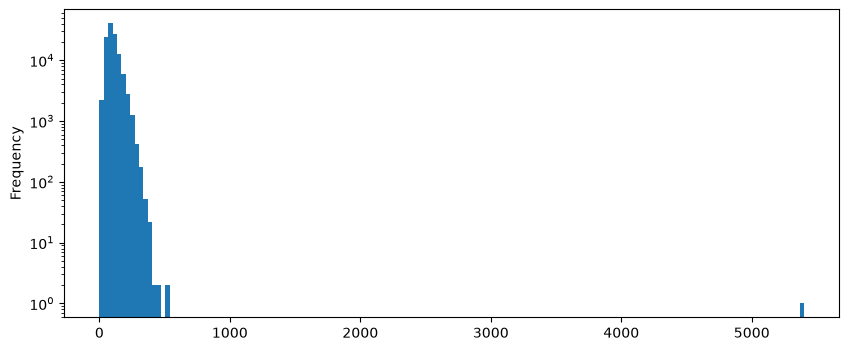

In [27]:
display(HTML(f'<b style="font-size: 14px"><i>Распределение цен:</i></b><br>'))
display(raw['adr'].describe().round(2).to_frame().T)
print()
print(f"adr < 0:  {(raw['adr'] < 0).sum()}")
print(f"adr == 0: {(raw['adr'] == 0).sum()}")
print(f"adr > 1000: {(raw['adr'] > 1000).sum()}\n")

raw.loc[raw['adr'] > 0, 'adr'].plot(kind='hist', bins=160, logy=True, figsize=(10, 4))

In [28]:
display(HTML(f'<b style="font-size: 14px"><i>Распределение цен по отелям:</i></b><br>'))
display(raw.groupby('hotel')['adr'].describe().round(1))

high_adr = raw[raw['adr'] > 400]
display(HTML(f'<br><b style="font-size: 14px"><i>Записи с ценами > 400:</i></b><br>'))
display(high_adr[['adr', 'hotel', 'market_segment', 'reserved_room_type', 'arrival_date_month']]
      .sort_values('adr', ascending=False).head(20))

,count,mean,std,min,25%,50%,75%,max
hotel,,,,,,,,
City Hotel,79330.0,105.3,43.6,0.0,79.2,99.9,126.0,5400.0
Resort Hotel,40060.0,95.0,61.4,-6.4,50.0,75.0,125.0,508.0


,adr,hotel,market_segment,reserved_room_type,arrival_date_month
48515,5400.00,City Hotel,Offline TA/TO,A,March
111403,510.00,City Hotel,Offline TA/TO,A,May
15083,508.00,Resort Hotel,Corporate,A,July
103912,451.50,City Hotel,Direct,E,December
13142,450.00,Resort Hotel,Online TA,A,August
13391,437.00,Resort Hotel,Direct,H,August
39155,426.25,Resort Hotel,Direct,G,August
39568,402.00,Resort Hotel,Online TA,H,August


In [29]:
adr_per_room_rype = pd.concat(
    {
        rt: raw.loc[raw['reserved_room_type'] == rt, 'adr'].describe()
        for rt in sorted(raw['reserved_room_type'].unique())
    },
    axis=1,
).round(1)

display(HTML(f'<b style="font-size: 14px"><i>Распределение цен по типам номеров:</i></b><br>'))
display(adr_per_room_rype)

,A,B,C,D,E,F,G,H,L,P
count,85994.0,1118.0,932.0,19201.0,6535.0,2897.0,2094.0,601.0,6.0,12.0
mean,90.8,90.4,160.2,120.7,124.5,167.7,176.0,188.2,124.7,0.0
std,41.8,34.5,71.5,48.0,59.9,63.6,79.5,75.9,69.5,0.0
min,-6.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0
25%,65.0,77.2,108.5,85.4,77.0,133.0,115.0,126.5,95.5,0.0
50%,89.0,87.0,163.0,120.7,114.8,177.0,175.4,184.0,143.0,0.0
75%,112.0,103.0,212.6,150.3,166.2,208.6,236.0,241.0,166.5,0.0
max,5400.0,284.1,367.0,375.5,451.5,392.0,426.2,437.0,200.0,0.0


In [30]:
count_zero = {
                rt: int(raw.loc[(raw['reserved_room_type'] == rt) & (raw['adr'] == 0), 'adr'].count())
                for rt in sorted(raw['reserved_room_type'].unique())
            }

df_count_zero = pd.DataFrame(
    {'count_adr_zero': count_zero}
).rename_axis('reserved_room_type')

display(HTML(f'<b style="font-size: 14px"><i>Нулевые цены по номерам:</i></b><br>'))
display(df_count_zero.T)

reserved_room_type,A,B,C,D,E,F,G,H,L,P
count_adr_zero,1420,33,19,196,112,73,88,6,0,12


In [31]:
display(HTML(f'<b style="font-size: 14px"><i>Запись с отрицательной ценой:</i></b><br>'))
display(raw[raw['adr'] < 0].T)

,14969
hotel,Resort Hotel
is_canceled,0
lead_time,195
arrival_date_year,2017
arrival_date_month,March
arrival_date_week_number,10
arrival_date_day_of_month,5
stays_in_weekend_nights,4
stays_in_week_nights,6
adults,2


In [32]:
zero_adr = raw[raw['adr'] == 0]
display(HTML(f'<b style="font-size: 14px"><i>Статистика по ard = 0:</i></b><br>'))
display(zero_adr['market_segment'].value_counts().to_frame().T)
display(HTML(f'<b style="font-size: 14px"><i>Распределение нулевых цен по отелям:</i></b><br>'))
display(zero_adr['hotel'].value_counts().to_frame())

market_segment,Complementary,Online TA,Offline TA/TO,Groups,Direct,Corporate,Aviation
count,680,367,332,252,240,82,6


,count
hotel,
City Hotel,1208
Resort Hotel,751


<div style = "border-left: 5px solid green; padding-left: 25px">
    <b style="font-size: 18px">Наблюдения:</b>
    <ul>
        <li>adr < 0 (1 строка) - почти наверняка ошибка</li>
        <li>adr = 0 (1959 строк) - 35% из сегмента Complementary, что вполне возможно. Остальные - записи вызывают больше вопросов, но из-за отсутствия дополнительной информации и большим количеством подобных записей (по сравнению с другими ошибками) - вероятно не ошибки</li>
        <li>adr = 5400 (1 строка) - разрыв в 10 раз от следующего значения - почти наверняка ошибка ввода</li>
        <li>adr 400–510 - разделяются на Resort-August и два City-случая (510 - A/may (подозрительная запись), 451.5 - типа E)</li>
    </ul>
    Вероятные ошибки только < 0 значение и 5400, стоит удалить.<br>
    Остальные вероятно корректные, их стоит оставить.
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Блок аудита колонок "agent", "company"</b><br>
        Далее будет проведён аудит колонок "agent", "company", так как многие из значений пустые.
    </p>
</div>

In [33]:
display(HTML(f'<b style="font-size: 14px"><i>Статистика по agent: всего уникальных {raw['agent'].nunique()}</i></b><br>'))
display(raw['agent'].describe().round(1).to_frame().T)
display(raw['agent'].value_counts().head(10).to_frame().T)

display(HTML(f'<b style="font-size: 14px"><i>Статистика по company:</i> всего уникальных {raw['company'].nunique()}</b><br>'))
display(raw['company'].describe().round(1).to_frame().T)
display(raw['company'].value_counts().head(10).to_frame().T)

,count,mean,std,min,25%,50%,75%,max
agent,103050.0,86.7,110.8,1.0,9.0,14.0,229.0,535.0


agent,9.0,240.0,1.0,14.0,7.0,6.0,250.0,241.0,28.0,8.0
count,31961,13922,7191,3640,3539,3290,2870,1721,1666,1514


,count,mean,std,min,25%,50%,75%,max
company,6797.0,189.3,131.7,6.0,62.0,179.0,270.0,543.0


company,40.0,223.0,67.0,45.0,153.0,174.0,219.0,281.0,154.0,405.0
count,927,784,267,250,215,149,141,138,133,119


<div style = "border-left: 5px solid green; padding-left: 25px">
    <b style="font-size: 18px">Наблюдения:</b>
    <ul>
        <li>agent: 333 уникальных, диапазон 1–535, без аномалий. Agent 240 доминирует - 31 961 бронь</li>
        <li>company: 352 уникальных, диапазон 6–543, распределение плоское (нет доминирующих компаний), +-6% строк заполнено</li>
    </ul>
    Все записи корректные
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Блок аудита колонок с типами номеров, статусов брони</b><br>
        Далее будет проведён аудит колонок с типами номеров (т.к. assigned_room_type имеет больше уникальных значений, чем reserved_room_type), а такде статусов брони.
    </p>
</div>

In [34]:
diff = raw[raw['reserved_room_type'] != raw['assigned_room_type']]
display(HTML(f'<b style="font-size: 14px"><i>Статистика по смене номеров:</i></b><br>'))
print(f"Different room types: {len(diff)}")
print(f"Share: {len(diff)/len(raw)*100:.1f}%")
changed = raw[raw['reserved_room_type'] != raw['assigned_room_type']]
display(changed.groupby(['reserved_room_type', 'assigned_room_type']).size().sort_values(ascending=False).head(10).to_frame().T)
display(HTML(f'<br><b style="font-size: 14px"><i>Уникальные номера:</i></b><br>'))
display(pd.DataFrame(raw['reserved_room_type'].unique()).sort_values(by=0).T)
display(pd.DataFrame(raw['assigned_room_type'].unique()).sort_values(by=0).T)

Different room types: 14917
Share: 12.5%


reserved_room_type     A                      D    A    E    D    A     
assigned_room_type     D     C     E     B    E    F    F    A    I    K
0                   7548  1447  1156  1123  686  417  404  312  215  210

,1,9,0,2,3,5,4,6,7,8
0,A,B,C,D,E,F,G,H,L,P


,1,7,0,2,3,5,4,8,6,11,10,9
0,A,B,C,D,E,F,G,H,I,K,L,P


In [35]:
display(HTML(f'<b style="font-size: 14px"><i>Статусов брони:</i></b><br>'))
pd.crosstab(raw['is_canceled'], raw['reservation_status'])

reservation_status,Canceled,Check-Out,No-Show
is_canceled,,,
0,0,75166,0
1,43017,0,1207


<div style = "border-left: 5px solid green; padding-left: 25px">
    <b style="font-size: 18px">Наблюдения:</b>
    <ul>
        <li>Есть много записей, где изначально не был выбран тип номера. Также столбец assigned_room_type имеет 2 дополнительных уникальных значения K и I, вероятно, это особые номера при замене</li>
        <li>Данные в столбце reservation_status соотноситься со столбцом is_canceled, что подтверждает корректность данных в столбце</li>
    </ul>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Блок аудита дат</b><br></p>
</div>

In [36]:
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
arrival_date = pd.to_datetime(dict(
    year=raw['arrival_date_year'],
    month=raw['arrival_date_month'].map(month_map),
    day=raw['arrival_date_day_of_month'],
), errors='coerce')

display(HTML(f'<b style="font-size: 14px"><i>Невалидные даты:</i> {arrival_date.isna().sum()}</b><br>'))
display(HTML(f'<b style="font-size: 14px"><i>Диапазон дат</i> {arrival_date.min()} - {arrival_date.max()}</b><br>'))

In [37]:
status_date = pd.to_datetime(raw['reservation_status_date'])
checkout_mask = raw['reservation_status'] == 'Check-Out'
violations = checkout_mask & (status_date < arrival_date)

display(HTML(f'<b style="font-size: 14px"><i>Выезд до заезда:</i> {violations.sum()}</b><br>'))

<div style = "border-left: 5px solid green; padding-left: 25px">
    <b style="font-size: 18px">Наблюдения:</b>
    <ul>
        <li>Все даты валидны и корректно записаны, ошибок нет</li>
        <li>Нет записей, где ввыезд был раньше заезда, в данных столбцах ошибок нет</li>
    </ul>
</div>

<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
    <b style="font-size: 35px">Типы данных</b>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Аудит типов данных</b><br>
        Далее будут проанализированны данные и предложены изменения (или отсутствие таковых), а также проверка их на тестовом массиве.
    </p>
</div>

In [38]:
display(raw.dtypes.to_frame(name='dtype'))

,dtype
hotel,str
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,str
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Предложение по изменению типов</b><br></p>
    <ul>
        <li>Добавить столбце с форматом даты %Y-%m-%d для удобного анализа в дальнейшем</li>
        <li>Столбцы children, company, agent перевести в тип int, заменив пропуски 0, так как значения в данных столбцах float только из-за пропусков (столбцы company, agent можно сделать категориальными)</li>
        <li>Сделать категориальными столбцы: arrival_date_month, hotel, meal, market_segment, distribution_channel, customer_type, deposit_type, reservation_status, reserved_room_type, assigned_room_type, country, для удобства анализа</li>
    </ul>
</div>

In [39]:
test = raw.copy()
test['reservation_status_date'] = pd.to_datetime(test['reservation_status_date'], format='%Y-%m-%d')
test['children'] = test['children'].fillna(0).astype('int64')
test['agent'] = test['agent'].fillna(0).astype('int64')
test['company'] = test['company'].fillna(0).astype('int64')
test['arrival_date_month'] = pd.Categorical(
    raw['arrival_date_month'],
    categories=['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December'],
    ordered=True,
)
test['hotel'] = test['hotel'].astype('category')
test['meal'] = test['meal'].astype('category')
test['market_segment'] = test['market_segment'].astype('category')
test['distribution_channel'] = test['distribution_channel'].astype('category')
test['customer_type'] = test['customer_type'].astype('category')
test['deposit_type'] = test['deposit_type'].astype('category')
test['reservation_status'] = test['reservation_status'].astype('category')
test['reserved_room_type'] = test['reserved_room_type'].astype('category')
test['assigned_room_type'] = test['assigned_room_type'].astype('category')
test['country'] = test['country'].astype('category')


display(test.dtypes.to_frame())

,0
hotel,category
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,category
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


<div style = "border-left: 15px solid green; padding-left: 25px">
    <b style="font-size: 28px">Общие вывод по аудиту данных:</b>
    <ul style="font-size: 18px">
        <li>Есть некоторые ошибки в виде пропусков в колонках children и country. В первой предлагается заменить такие значения на 0, во второй на "unknow"</li>
        <li>Пропуски в колонках agent и company не являются ошибками и такие значения предлагается заменить на 0, чтобы привести колонки к типу int. Колонку company можно удалить, т.к. она правтически не несёт полезной информации</li>
        <li>Среди записей много дубликатов, из-за чего предлагается ввести отдельный столбец, который покажет подобные записи. В последствии анализ можно будет проводить по двум выборкам (с дубликатами и без)</li>
        <li>В столбцах adult, children и babies записи со всеми значениями 0 по столбцам стоит удалить. Записи с количеством гостей > 5 также являются странными и потенциальными ошибками, так же как и записи, где adult = 0</li>
        <li>Pаписи со значением adr < 0 и adr = 5400 ошибки, требующие удаления</li>
        <li>Стоит добавить столбец с форматом даты %Y-%m-%d для удобного анализа в дальнейшем</li>
        <li>Столбцы children, company, agent стоит конвертировать в тип int, заменив пропуски 0</li>
        <li>Стоит сделать категориальными столбцы: arrival_date_month, hotel, meal, market_segment, distribution_channel, customer_type, deposit_type, reservation_status, reserved_room_type, assigned_room_type, country, для удобства анализа</li>
    </ul>
</div>

<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
    <b style="font-size: 35px">Применение методов очистки</b>
</div>

In [40]:
clean = raw.copy()

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>0 гостей в записи</b><br></p>
    Так как подобных записей не одна, а также значение гостей не NaN, то стоит ещё раз удостовериться, стоит ли удалять эти записи или лучше воспринимать их как корректные (например неопределённое количество гостей)
</div>

In [41]:
empty = clean[(clean['adults']==0) & (clean['children']==0) & (clean['babies']==0)]
display(empty[['adr', 'stays_in_weekend_nights', 'stays_in_week_nights', 'total_of_special_requests', 'booking_changes', 'is_canceled']].describe().round(2))

,adr,stays_in_weekend_nights,stays_in_week_nights,total_of_special_requests,booking_changes,is_canceled
count,180.00,180.00,180.00,180.00,180.00,180.00
mean,10.46,1.29,3.23,0.48,1.76,0.14
std,31.68,2.35,5.61,0.74,3.15,0.35
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,1.00,0.00,1.00,0.00
75%,0.00,2.00,4.00,1.00,2.00,0.00
max,200.00,16.00,41.00,3.00,21.00,1.00


<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px">Так данные в других колонках данных столбцов корректные, то оставим данные брони в исходном состоянии</p>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Только дети в записях</b><br>
    Подобные записи могут быть либо особенностью оформления (отдельные номера для детей), либо особые мероприятия: детские экскурсии, лагерь и т.д.</p><br>
    <p style="font-size: 16px"><b>babies >= 9, children = 10, adr < 0, adr = 5400</b><br>
    Почти наверняка ошибки в записях. Удалим данные строки</p>
</div>

In [42]:
mask = (clean['adr'] < 0) | (clean['adr'] > 1000) | (clean['babies'] >= 9) | (clean['children'] == 10)
clean = clean[~mask]

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>adults > 5</b><br>
    Данные строки содержат market_segment = Direct/Groups, customer_type = Group, все отменены, total_of_special_requests = 0. Удаление исказит сегмент Groups и особенно его cancellation rate. Так как остальные параметры выглядят "реальными", то данные строки оставим</p>
</div>

In [43]:
print(f"Rows after delete raw: {len(raw)}")
print(f"Rows after delete clean: {len(clean)}")

Rows after delete raw: 119390
Rows after delete clean: 119385


<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Пропуски в столбце children</b><br>
    Данные пропуски заполним значением медианы - 0</p>
</div>

In [44]:
clean['children'] = clean['children'].fillna(0)

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Пропуски в country</b><br>
    В данном столбце страны - это категории и лучше сохранить такой "шаблон", поэтому заполним новой категорией "Unknown"</p>
</div>

In [45]:
clean['country'] = clean['country'].fillna('Unknown')

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Столбцы agent и company</b><br>
    Данные столбцы также представляют категории, поэтому пустые значения стоит заменить на 0, чтобы показать отсутствие компании или агента через которого бранировали</p>
</div>

In [46]:
clean['agent'] = clean['agent'].fillna(0)
clean['company'] = clean['company'].fillna(0)

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Дубликаты</b><br>
Предлагается пометить "избыточные" дубликаты в колонки is_duplicated. Без booking_id невозможно отличить технический дубль от реальной брони. Удаление исказило бы сегментный анализ. Флаг позволяет в проверить чувствительность выводов: сравнить метрики на полном датасете и на подмножестве ~is_duplicated.
    </p>
</div>

In [47]:
clean['is_duplicated'] = clean.duplicated(keep='first')

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Преобразование типов</b><br>
        Далее будет произведено преобразование типов колонок, которое было произведено ранее
    </p>
</div>

In [48]:
clean['reservation_status_date'] = pd.to_datetime(clean['reservation_status_date'], format='%Y-%m-%d')
clean['children'] = clean['children'].fillna(0).astype('int64')
clean['agent'] = clean['agent'].fillna(0).astype('int64')
clean['company'] = clean['company'].fillna(0).astype('int64')
clean['arrival_date_month'] = pd.Categorical(
    clean['arrival_date_month'],
    categories=['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December'],
    ordered=True,
)
clean['hotel'] = clean['hotel'].astype('category')
clean['meal'] = clean['meal'].astype('category')
clean['market_segment'] = clean['market_segment'].astype('category')
clean['distribution_channel'] = clean['distribution_channel'].astype('category')
clean['customer_type'] = clean['customer_type'].astype('category')
clean['deposit_type'] = clean['deposit_type'].astype('category')
clean['reservation_status'] = clean['reservation_status'].astype('category')
clean['reserved_room_type'] = clean['reserved_room_type'].astype('category')
clean['assigned_room_type'] = clean['assigned_room_type'].astype('category')
clean['country'] = clean['country'].astype('category')


display(clean.dtypes.to_frame())

,0
hotel,category
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,category
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [49]:
print(f"Shape: {clean.shape}")
print(f"\nDtypes:\n{clean.dtypes.value_counts()}")
print(f"\nAny NaN left: {clean.isna().sum().sum()}")

Shape: (119385, 33)

Dtypes:
int64             19
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
float64            1
category           1
datetime64[us]     1
bool               1
Name: count, dtype: int64

Any NaN left: 0


<div style = "border-left: 5px solid green; padding-left: 25px">
    <b style="font-size: 18px">Промежуточный вывод:</b><br>
    В данный момент массив clean является очищенным и готовым к дальнейшему анализу. Были исправлены пропуски, ошибки ввода и типы данных
</div>

<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
    <b style="font-size: 35px">Производные признаки</b>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Добавим следующие полезные признаки,</b> которые помогут при анализе данных в будущем:
        <ul>
            <li>total_nights: stays_in_weekend_nights + stays_in_week_nights. Общая длительность проживания в ночах, основа для метрик загрузки, среднего срока пребывания и расчёта выручки</li>
            <li>total_revenue: adr * total_nights. Номинальная выручка от брони. Будет полезно при формировании "потерь" и иных показателей</li>
            <li>total_guests: adults + children + babies. Общее число гостей в брони, позволяет анализировать размер группы, среднее число гостей на номер</li>
            <li>booking_date: arrival_date − lead_time. Расчётная дата бронирования, позволяет строить временные ряды «когда бронируют» — в отличие от arrival_date, который показывает «когда заезжают».</li>
        </ul>
    </p>
</div>

In [50]:
clean['total_nights'] = clean['stays_in_weekend_nights'] + clean['stays_in_week_nights']
clean['total_revenue'] = clean['adr'] * clean['total_nights']
clean['total_guests'] = clean['adults'] + clean['children'] + clean['babies']
clean['booking_date'] = pd.to_datetime(dict(
    year=clean['arrival_date_year'],
    month=clean['arrival_date_month'].cat.codes + 1,
    day=clean['arrival_date_day_of_month'],
)) - pd.to_timedelta(clean['lead_time'], unit='D')

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Проверка новых признаков на корректность</b></p>
</div>

In [51]:
print(f"Shape: {clean.shape}")          # ожидается (119385, 37)
print(clean[['total_nights', 'total_revenue', 'total_guests', 'booking_date']].dtypes)

Shape: (119385, 37)
total_nights              int64
total_revenue           float64
total_guests              int64
booking_date     datetime64[us]
dtype: object


In [52]:
print(f"NaN in new cols: {clean[['total_nights', 'total_revenue', 'total_guests', 'booking_date']].isna().sum().sum()}")

NaN in new cols: 0


In [53]:
print(clean[['total_nights', 'total_revenue', 'total_guests']].describe().round(2))
print(f"booking_date range: {clean['booking_date'].min()} → {clean['booking_date'].max()}")

       total_nights  total_revenue  total_guests
count     119385.00      119385.00     119385.00
mean           3.43         357.80          1.97
std            2.56         335.57          0.72
min            0.00           0.00          0.00
25%            2.00         146.00          2.00
50%            3.00         267.00          2.00
75%            4.00         446.25          2.00
max           69.00        7590.00         55.00
booking_date range: 2013-06-24 00:00:00 → 2017-08-31 00:00:00


In [54]:
sample = clean.loc[clean['lead_time'] == 100].iloc[0]
print(f"arrival:    {sample['arrival_date_year']}-{sample['arrival_date_month']}-{sample['arrival_date_day_of_month']}")
print(f"lead_time:  {sample['lead_time']}")
print(f"booking:    {sample['booking_date']}")

arrival:    2015-July-4
lead_time:  100
booking:    2015-03-26 00:00:00


<div style = "border-left: 5px solid green; padding-left: 25px">
    <b style="font-size: 18px">Промежуточный вывод:</b><br>
    Все производные признаки созданы корректно и могут быть использованы далее
</div>

<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
    <b style="font-size: 35px">Сохранение данных</b>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Далее будет произведено сохранение данных в файл csv</b></p>
</div>

In [55]:
OUTPUT_PATH = ROOT / "data" / "processed" / "hotels_clean.csv"
clean.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")
print(f"Size: {OUTPUT_PATH.stat().st_size / 1024 / 1024:.1f} MB")

Saved: C:\Users\tms05\projects\hotel-cancellation-analysis\data\processed\hotels_clean.csv
Size: 19.1 MB


<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Проверка файла на корректность сохранения</b></p>
</div>

In [56]:
check = pd.read_csv(OUTPUT_PATH, parse_dates=['reservation_status_date', 'booking_date'])
print(f"Shape: {check.shape}")
print(f"Any NaN: {check.isna().sum().sum()}")
print(check.dtypes.value_counts())

Shape: (119385, 37)
Any NaN: 0
int64             21
str               11
float64            2
datetime64[us]     2
bool               1
Name: count, dtype: int64


<div style = "border-left: 15px solid green; padding-left: 25px">
    <b style="font-size: 28px">Общий вывод:</b>
    <ul style="font-size: 18px">
        <li>Был произведён аудит данных и найдены потенциальные ошибки</li>
        <li>Были удалены записи babies >= 9, children = 10, adr < 0, adr = 5400</li>
        <li>Были заполнены пропуски либо 0, либо Unkown</li>
        <li>В новом столбце были отмечены дубликаты</li>
        <li>Были сделаны приведения типов столбцов к int, заместо float в столбцах с пропусками, к category в столбцах с категориями</li>
        <li>Были созданы произодные признаки: общее количество ночей, общее количество гостей, общее стоимость брони, дата бронирования</li>
        <li>Очищенные данные были сохранены в файл csv</li>
    </ul>
</div>